In [252]:
print("importing...")
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("imported!")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 120
})

DATA_PATH = r"C:\Users\Jorick\code\mosaic-ms\master\Mosaic-MS\snakemake\effect_of_k\results\final_scores_summary.csv"

print("Libraries imported successfully.")

importing...
imported!
Libraries imported successfully.


In [253]:
df = pd.read_csv(DATA_PATH)

In [254]:
def accuracy_plot(full_df, graph_type):
    df = full_df[full_df["graph_type"] == graph_type]
    
    fig, axes = plt.subplots(1, 4, figsize=(10, 3), sharex=True, sharey=True)
    axes = axes.flatten()  # Flatten 2D array of axes into 1D array for easy iteration

    # Define similarity types and quality categories
    similarity_types = ['cos', 'modcos', 'spec2vec', 'ms2deepscore']
    categories = ['good', 'miss', 'poor']
    colors = ['#2ca02c', '#ff7f0e', '#d62728']  # Optional distinct colors: Green, Orange, Red

    # 2. Iterate and plot each similarity type
    for idx, sim_type in enumerate(similarity_types):
        ax = axes[idx]
        
        # Filter for base graph and current similarity type
        sub_df = df[df['similarity_type'] == sim_type]
        
        if not sub_df.empty:
            # Index by x-axis variable
            df_indexed = sub_df.set_index('k')[categories].fillna(0).sort_index()
            
            # Plot stacked area
            ax.stackplot(
                df_indexed.index, 
                [df_indexed[cat] for cat in categories], 
                labels=['Good', 'Miss', 'Poor'],
                colors=colors,
                alpha=0.8
            )
        
        # Titles & Inversion
        ax.set_title(f'{sim_type}', fontsize=12)
        ax.grid(True, linestyle='-', alpha=0.5)

    # 3. Axis labels for shared grid
    fig.supxlabel('k', fontsize=12, y=0.10)
    fig.supylabel('Number of Annotations', fontsize=12, x=0.05)

    # Single unified legend for all subplots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Category', loc='upper right', bbox_to_anchor=(0.98, 0.65))
    plt.tight_layout(rect=[0.03, 0.03, 0.88, 0.95])
    plt.gca().invert_xaxis()
    plt.ylim(bottom=0)
    plt.ylim(top=2100)
    plt.show()

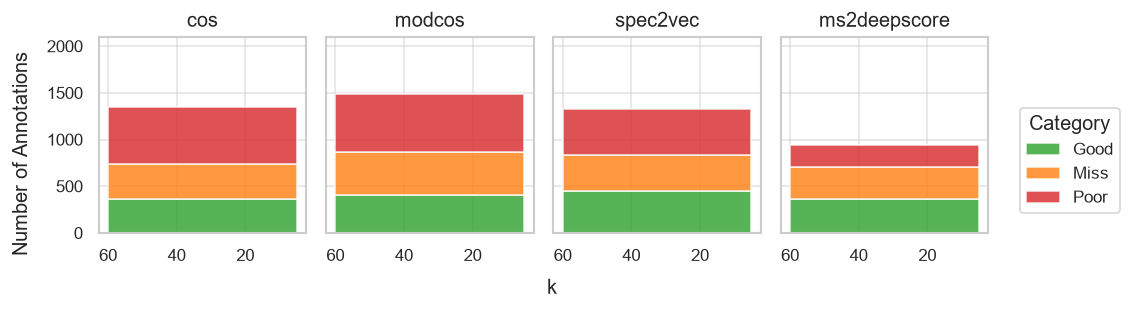

In [255]:
accuracy_plot(df, "base") # sanity check

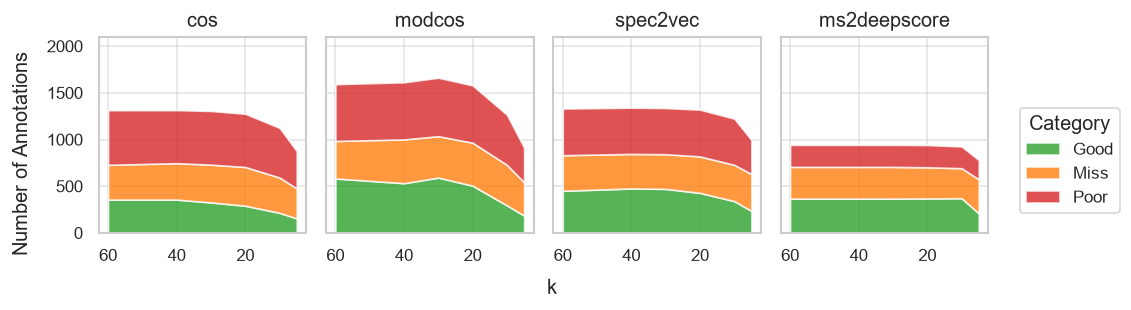

In [256]:
accuracy_plot(df, "threshold")

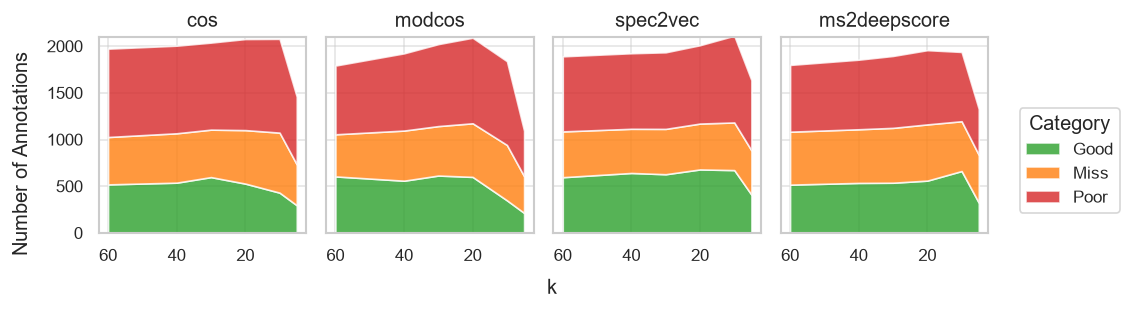

In [257]:
accuracy_plot(df, "rescued")

In [258]:
def line_accuracy_plot(full_df, graph_type):
    graph_type 
    df = full_df[full_df["graph_type"] == graph_type]
    base_df = full_df[full_df["graph_type"] == "base"]
    fig, axes = plt.subplots(1, 4, figsize=(10, 3), sharex=True, sharey=True)
    axes = axes.flatten()  # Flatten 2D array of axes into 1D array for easy iteration

    # Define similarity types and quality categories
    similarity_types = ['cos', 'modcos', 'spec2vec', 'ms2deepscore']

    # 2. Iterate and plot each similarity type
    for idx, sim_type in enumerate(similarity_types):
        ax = axes[idx]
        
        # Filter for base graph and current similarity type
        sub_df = df[df['similarity_type'] == sim_type]

        sub_base_df = base_df[base_df['similarity_type'] == sim_type]
        
        if not sub_df.empty:
            # Index by x-axis variable
            # Plot stacked area
            ax.plot(
                sub_df["k"], 
                (sub_df["good"]) / (sub_df["good"] + sub_df["miss"] + sub_df["poor"]), label=graph_type
            )
            ax.plot(
                sub_base_df["k"], 
                (sub_base_df["good"]) / (sub_base_df["good"] + sub_base_df["miss"] + sub_base_df["poor"]), label="base"
            )
        
        # Titles & Inversion
        ax.set_title(f'{sim_type}', fontsize=12)
        ax.grid(True, linestyle='-', alpha=0.5)

    fig.supxlabel('k', fontsize=12, y=0.10)
    fig.supylabel('Accuracy (good / total_annotated)', fontsize=12, x=0.05)
    plt.tight_layout(rect=[0.03, 0.03, 0.88, 0.95])
    plt.legend()
    plt.show()

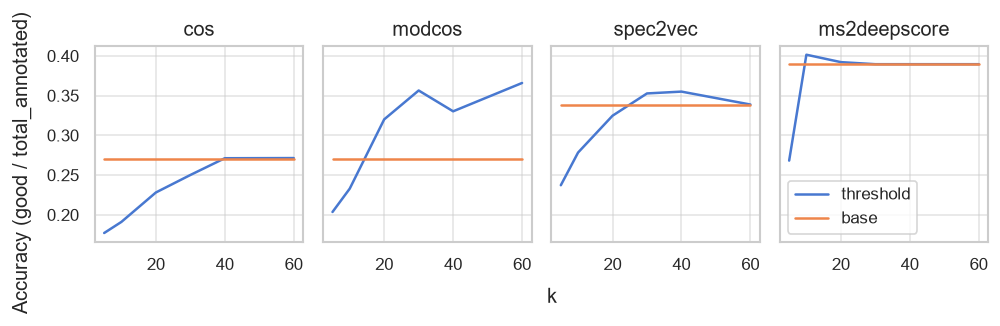

In [259]:
line_accuracy_plot(df, "threshold")

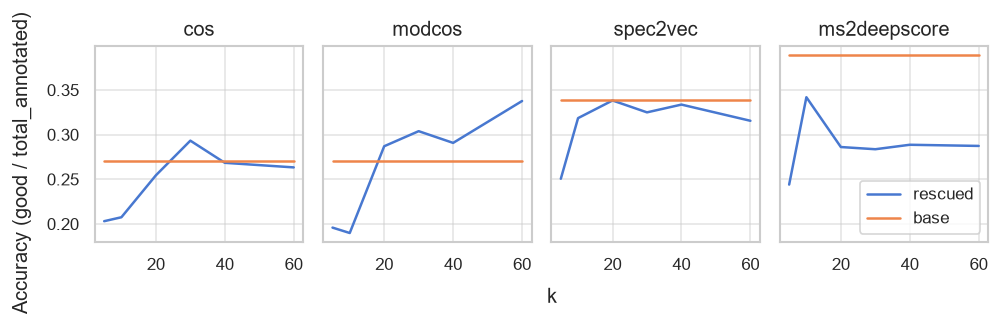

In [260]:
line_accuracy_plot(df, "rescued")

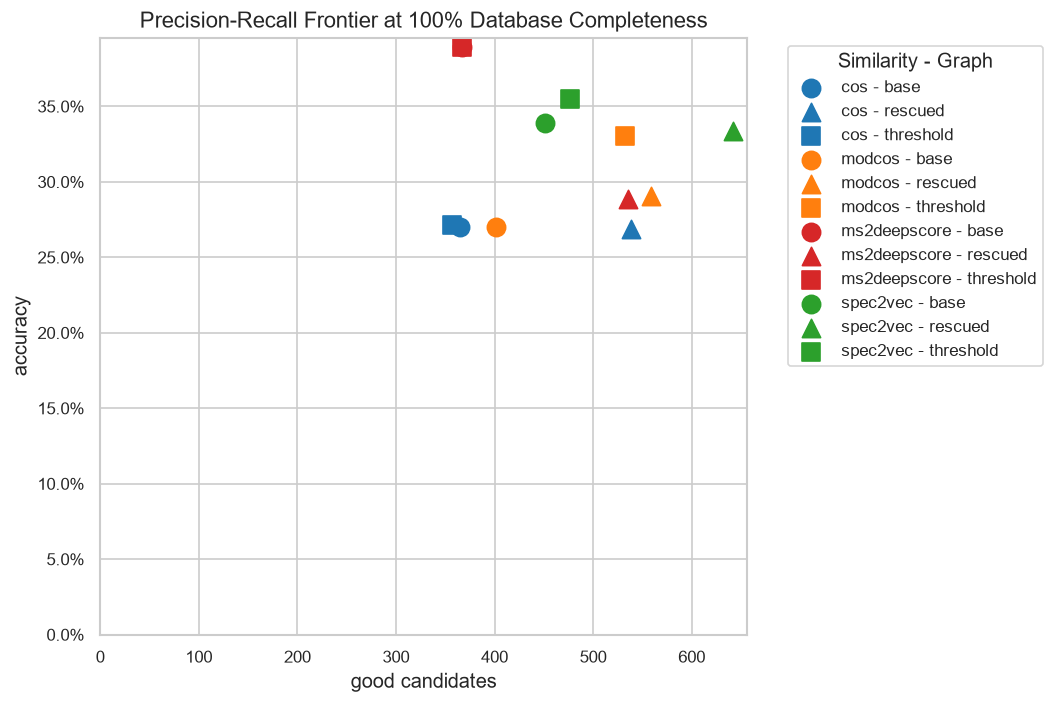

In [261]:
import matplotlib.pyplot as plt


# 1. Filter dataset
filtered_df = df[df['k'] == 40]

plt.figure(figsize=(9, 6))

# 2. Define distinct colors for 'similarity_type' and markers for 'graph_type'
sim_types = filtered_df['similarity_type'].unique()
graph_types = filtered_df['graph_type'].unique()

colors = plt.cm.tab10(range(len(sim_types)))
markers = ['o', 's', '^', 'D', 'v', '<', '>'][:len(graph_types)]

color_map = dict(zip(sim_types, colors))
marker_map = dict(zip(graph_types, markers))

# 3. Plot each group separately to handle hue + style
for (sim, graph), group in filtered_df.groupby(['similarity_type', 'graph_type']):
    plt.scatter(
        (group['good']),
        (group['good']) / (group['good'] + group['miss'] + group['poor']),
        color=color_map[sim],
        marker=marker_map[graph],
        s=120,
        label=f"{sim} - {graph}"
    )

# 4. Axes limits and labels
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.title('Precision-Recall Frontier at 100% Database Completeness')
plt.xlabel('good candidates')
plt.ylabel('accuracy')

# 5. Format axes ticks as percentages properly using PercentFormatter
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

# 6. Legend and layout
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Similarity - Graph')
plt.tight_layout()
plt.show()